# Deep Learning for Dynamic Medication Treatment Recommendation

## Learning Guide: What is this project?

Welcome! This notebook implements a **Supervised Reinforcement Learning (SRL-RNN)** model. If you are new to machine learning, here are the core concepts you will learn and use in this project:

### 1. The Problem
We want to recommend medications for patients in the ICU. The challenge is that a patient's condition changes over time (Dynamic), and the "best" medication schedule isn't always clear (Uncertainty).

### 2. The Data
We use **MIMIC-III**, a large database of ICU patients.
- **Input (State)**:
    - **Demographics**: Static data like Age, Gender (doesn't change much).
    - **Diagnoses**: Medical codes (ICD-9) representing what diseases the patient has.
    - **Lab Tests**: Time-series data (e.g., Heart Rate, Blood Pressure) measured over 24-48 hours.
- **Output (Action)**:
    - **Medications**: A set of drugs (e.g., Antibiotics, Vasopressors) to prescribe.

### 3. The Solution: "Actor-Critic" Reinforcement Learning
We treat the doctor as an "Agent" that takes actions (prescribes meds) to maximize a reward (patient survival).

*   **RNN (Recurrent Neural Network) / LSTM (Long Short-Term Memory)**:
    *   Since patient data is a sequence (time-series), we use LSTMs. LSTMs have a "memory" that helps them understand trends (e.g., "Blood pressure is dropping fast").
    
*   **Actor Network**:
    *   **Role**: The "Doctor". It sees the patient state and proposes medications.
    *   **Training**: It tries to predict the *actual* doctor's orders (Supervised Learning) AND maximize the survival reward (Reinforcement Learning).
    
*   **Critic Network**:
    *   **Role**: The "Evaluator". It looks at the patient state and the stored Action, and predicts how "good" that action is (The "Q-Value").
    *   **Training**: It learns by comparing its prediction to the actual outcome (Did the patient survive? Did they improve?).

### 4. How Training Works
1.  **Forward Pass**: The Actor sees data -> Predicts Meds. The Critic sees data + Meds -> Predicts Outcome Score.
2.  **Loss Calculation**: 
    - **Supervised Loss**: Did the Actor predict the same meds as the real doctor? (Binary Cross Entropy)
    - **RL Loss**: Did the Actor pick meds that the Critic thinks are good? (Maximize Critic Score)
3.  **Backpropagation**: We calculate gradients and update the model weights to reduce error.

---
**Authors**: Zhengpei Cheng, Nicholas Daponte
**Refactored for Education**: March 2026


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import jaccard_score, accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import drive # Removed as we are running locally, handled in cleanup

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# **Introduction**

## Background of the problem
  * **What type of problem: disease/readmission/mortality prediction,  feature engineeing, data processing, etc :**
The problem addressed in the paper is treatment recommendation in healthcare based on electronic health records (EHRs). It involves predicting optimal treatment strategies for patients based on their medical history, current condition, and other relevant factors. This problem falls under the domain of personalized medicine and healthcare optimization.
  * **What is the importance/meaning of solving the problem:**
  Solving the problem of treatment recommendation is crucial for improving patient outcomes and optimizing clinical decision-making. By leveraging EHR data, healthcare providers can tailor treatment plans to individual patients, leading to more effective interventions, reduced mortality rates, and better overall healthcare delivery. Furthermore, personalized treatment recommendations can enhance patient satisfaction and trust in the healthcare system.
  * **What is the difficulty of the problem:**
  One of the main challenges in treatment recommendation is the complexity and variability of patient data. EHRs contain diverse information, including medical history, lab results, vital signs, and demographics, making it challenging to extract meaningful insights and identify optimal treatment strategies. Additionally, the dynamic nature of patient health and the inherent uncertainty in medical outcomes add to the difficulty of the problem. Moreover, ensuring the safety and ethical soundness of treatment recommendations further complicates the task.
  * **The state of the art methods and effectiveness:**
  The paper discusses various approaches to treatment recommendation, including supervised learning (SL) and reinforcement learning (RL) techniques. Prior studies have explored SL methods to match diseases with medications based on expert systems but often struggle with personalization and lack of ground truth for "good" treatment strategies. RL approaches, particularly dynamic treatment regime (DTR) methods, offer a promising avenue by optimizing treatment decisions over time to maximize long-term patient outcomes. Deep RL models have shown effectiveness in learning optimal DTRs from EHR data, although challenges remain in aligning recommendations with doctors' prescriptions and handling the complexity of medication spaces. The proposed method, Supervised Reinforcement Learning with Recurrent Neural Network (SRL-RNN), aims to address these challenges by integrating SL and RL signals to learn a comprehensive treatment policy while leveraging RNNs to capture temporal dependencies in patient data
## Paper explanation
  * **What did the paper propose:**
  The paper proposed a novel deep architecture called Supervised Reinforcement Learning with Recurrent Neural Network (SRL-RNN) for dynamic treatment recommendation (DTR) systems based on large-scale electronic health records (EHRs). This approach combines supervised learning (SL) and reinforcement learning (RL) into a synergistic learning framework.
  * **What is the innovations of the method**:
  The main innovation of the SRL-RNN method lies in its ability to combine both supervised learning and reinforcement learning to handle complex relations among multiple medications, diseases, and individual characteristics. Unlike previous studies that focused solely on either SL or RL, SRL-RNN integrates both approaches to learn an integrated policy for treatment recommendation. Additionally, SRL-RNN utilizes an off-policy actor-critic framework and recurrent neural networks (RNNs) to address the challenges of analyzing longitudinal and temporal patient records and solving the Partially-Observed Markov Decision Process (POMDP) problem.
  * **how well the proposed method work (in its own metrics):**
  According to the paper's experimental results, SRL-RNN demonstrates promising performance in reducing estimated mortality in the hospital by 4.4% and providing better medication recommendations. These results are obtained through quantitative experiments and qualitative case studies conducted on the MIMIC-3 dataset, a publicly available real-world dataset.
  * **what is the contribution to the reasearch regime (referring the Background above, how important the paper is to the problem):**
  The paper's contribution to the research regime is significant as it addresses the limitations of existing approaches in treatment recommendation systems. By combining supervised learning and reinforcement learning in a synergistic manner, SRL-RNN offers a more generalizable and effective solution for DTR, especially in scenarios involving multiple diseases and medications. Moreover, the use of an off-policy actor-critic framework and RNNs enhances the model's ability to handle complex patient records and optimize treatment policies. Overall, the proposed method contributes to advancing the field of personalized medicine by leveraging large-scale EHR data to improve clinical decision-making.


  ## Example Treatment Reccomendation for a single patient hospital admission:

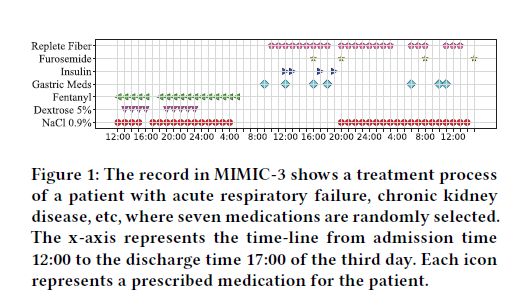

# Scope of Reproducibility:


1.   **Hypothesis 1:** Implementing the actor-critic framework using PyTorch instead of Keras and TensorFlow will yield comparable results in terms of treatment recommendation accuracy and mortality reduction on the MIMIC-3 dataset.

2.   **Hypothesis 2:** Adopting a preprocessing approach similar to the one used in the paper, which combines supervised learning and reinforcement learning signals, will lead to improved model performance in terms of reducing estimated mortality rates and providing better medication recommendations.




### Mount this notebook to google drive

In [ ]:
# no code is required for this section
'''
if you want to use an image outside this notebook for explanaition,
you can upload it to your google drive and show it with OpenCV or matplotlib
'''
# mount this notebook to your google drive
drive.mount('/content/gdrive')

# define dirs to workspace and data
#img_dir = '/content/gdrive/My Drive/Colab Notebooks/<path-to-your-image>'

#import cv2
#img = cv2.imread(img_dir)
#cv2.imshow("Title", img)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Methodology



In [ ]:
# Preliminary Packages
import numpy as np
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder


##  Data
Data includes raw data (MIMIC III tables), descriptive statistics (our homework questions), and data processing (feature engineering).
  * Source of the data: Data is collected from queried [ ] tables from the MIMIC-3 v1.4 database.
  According to original paper.
  
  First, we did bigquery SQL to get raw data. Then we extract target data on Google Cloud Platform by pandas and numpy.

* To ensure statistical significance, we extract the top 1,000 medications and top 2,000 diseases (represented by ICD-9 codes) which cover 85.4% of all medication records and 95.3% of all diagnosis records, respectively. In order to experiment on different granularity of medications, we map the 1,000 medications into the third level of ATC1 (medication codes) using RxNorm API, resulting 92 distinct ATC codes. Therefore, the action space size of the experiments is 1,000 exact medications (K = 1000) or 92 drug categories (K = 92).


* For each patient, we extract relevant physiological parameters
, which include static variables and time-series variables. The static variables cover eight kinds of demographics: gender, age, weight, height, religion, language, marital
status, and ethnicity.

* The time-series variables contain lab values,
vital signs, and output events, such as diastolic blood pressure,
fraction of inspiration O2, Glascow coma scale, blood glucose, systolic blood pressure, heart rate, pH, respiratory rate, blood oxygen
saturation, body temperature, and urine output.

* These features correspond to the state s in MDP or the observation o in POMDP. We impute the missing variable with k-nearest neighbors and remove
admissions with more than 5 missing variables. Each hospital admission of a patient is regarded as a treatment plan. Time-series
data in each treatment plan is divided into different units, each of
which is set to 24 hours since it is the median of the prescription
frequency in MIMIC-3. If several data points are in one unit, we
use their average values instead.

## Load Queried Data from MIMIC-3 v1.4 Database

In [ ]:
# Define data directory and loading function
RAW_DATA_DIR = './data/'

def load_raw_data(file_path):
    """
    Load raw data from CSV file into a pandas DataFrame.
    """
    try:
        df = pd.read_csv(file_path)
        return df
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None

def calculate_stats(raw_data):
    """
    Calculate and print statistics for the dataset.
    """
    if raw_data is not None:
        print(raw_data.describe())
        print(raw_data.info())
    else:
        print("No data to analyze.")

def process_data(raw_data):
    """
    Process raw data as needed (placeholder).
    """
    return raw_data

# Define file paths
# Static Variables
height_weight_file = 'Static_var_height_weight.csv'
other_static_var_file = 'Static_var_not_height_weight.csv'
height_weight_path = os.path.join(RAW_DATA_DIR, height_weight_file)
other_static_var_path = os.path.join(RAW_DATA_DIR, other_static_var_file)

# Time Series Variables
time_series_variables_file = 'Time_series_variables.csv'
time_series_variables_path = os.path.join(RAW_DATA_DIR, time_series_variables_file)

# Other Data
top_2000_diagnoses_file = 'top_2000_diagnoses.csv'
top_2000_diagnoses_path = os.path.join(RAW_DATA_DIR, top_2000_diagnoses_file)

third_lvl_atc_codes_file = 'unique_chosen_atc.csv'
third_lvl_atc_codes_path = os.path.join(RAW_DATA_DIR, third_lvl_atc_codes_file)

filtered_perscription_table_file = 'filtered_perscription_table.csv' # Note: Assuming this exists or is created by scripts
filtered_perscription_table_path = os.path.join(RAW_DATA_DIR, filtered_perscription_table_file)

filtered_diagnoses_table_file = 'filtered_diagnoses_table.csv' # Note: Assuming this exists or is created by scripts
filtered_diagnoses_table_path = os.path.join(RAW_DATA_DIR, filtered_diagnoses_table_file)

FINAL_FILTERED_PERSCRIPTION_TABLE_PATH = os.path.join(RAW_DATA_DIR, 'FINAL_FILTERED_MED.csv')


# Load Data
print("Loading data...")
height_weight_df = load_raw_data(height_weight_path)
other_static_var_df = load_raw_data(other_static_var_path)
time_series_variables_df = load_raw_data(time_series_variables_path)
top_2000_diagnoses_df = load_raw_data(top_2000_diagnoses_path)
third_lvl_atc_codes_df = load_raw_data(third_lvl_atc_codes_path)
# These files might not exist if they are intermediate outputs. Checking logic needed.
# For now, we try to load them if the original code did.
filtered_perscription_table_df = load_raw_data(filtered_perscription_table_path)
filtered_diagnoses_table_df = load_raw_data(filtered_diagnoses_table_path)
FINAL_FILTERED_PERSCRIPTION_TABLE_df = load_raw_data(FINAL_FILTERED_PERSCRIPTION_TABLE_PATH)

# Filter Logic (from original notebook)
if top_2000_diagnoses_df is not None:
    print("Shape of top_2000_diagnoses_df:", top_2000_diagnoses_df.shape)
    
    # ICD9_CODE (DIAGNOSIS) MATRIX
    # Step 1: Extract top 2000 unique ICD9_CODEs
    top_2000_icd9_codes = top_2000_diagnoses_df['ICD9_CODE'].unique()
    
    # Step 2: Filter filtered_diagnoses_table_df
    if filtered_diagnoses_table_df is not None:
        filtered_diagnoses_filtered = filtered_diagnoses_table_df[filtered_diagnoses_table_df['ICD9_CODE'].isin(top_2000_icd9_codes)]
        # Step 3: Group by HADM_ID and aggregate ICD9_CODEs into a list
        hadm_id_icd9_map = filtered_diagnoses_filtered.groupby('HADM_ID')['ICD9_CODE'].agg(list).to_dict()
        # Step 4: Print the dictionary
        print(f"Generated HADM_ID to ICD9 map for {len(hadm_id_icd9_map)} admissions.")
    else:
        print("Filtered diagnoses table not loaded, skipping map generation.")


Shape of top_2000_diagnoses_df: (2000, 2)


IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



## **Raw Data Statistics**


In [ ]:
def dead_alive_split(df):
  dead_people=df.loc[~df['DEATHTIME'].isnull(),'SUBJECT_ID'].unique().tolist()
  dead_encounter=df[df["SUBJECT_ID"].isin(dead_people)]
  alive_encounter=df[~df["SUBJECT_ID"].isin(dead_people)]
  return dead_encounter,alive_encounter
dead_encounter,alive_encounter=dead_alive_split(other_static_var_df)

def event_count_metrics(alive_encounter, dead_encounter):
  return alive_encounter.groupby('SUBJECT_ID').size().describe(),dead_encounter.groupby('SUBJECT_ID').size().describe()
alive_statistics,dead_statistics=event_count_metrics(dead_encounter,alive_encounter)

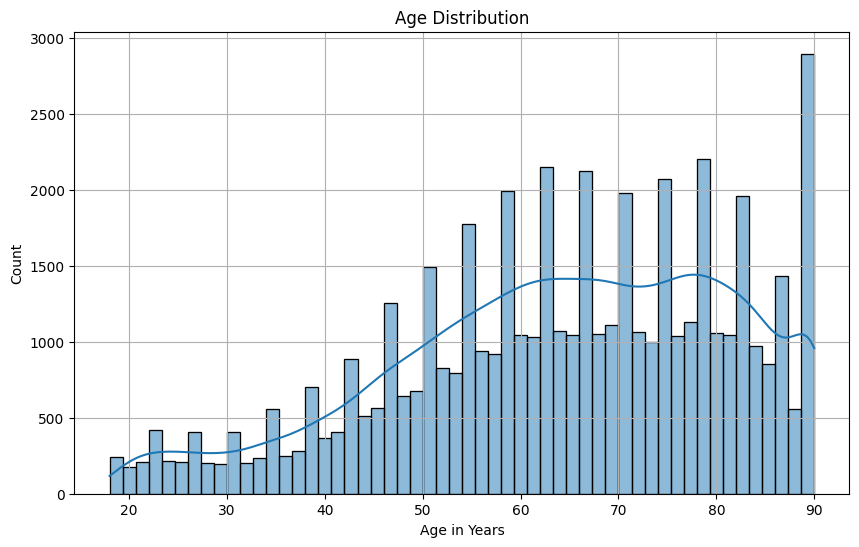

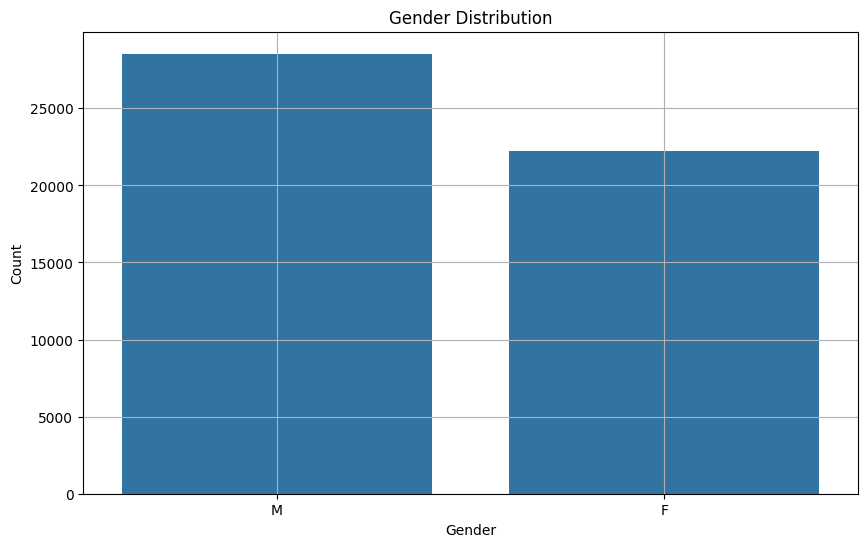

<ipython-input-6-3d06e6db7ca2>:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Proportion', y=column_name, data=df, ci=None)


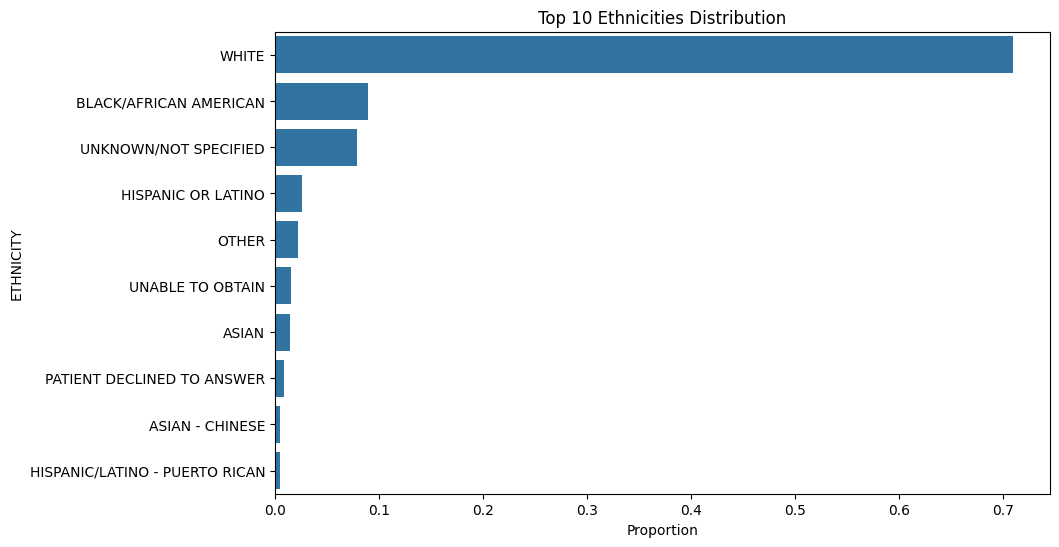

<ipython-input-6-3d06e6db7ca2>:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Proportion', y=column_name, data=df, ci=None)


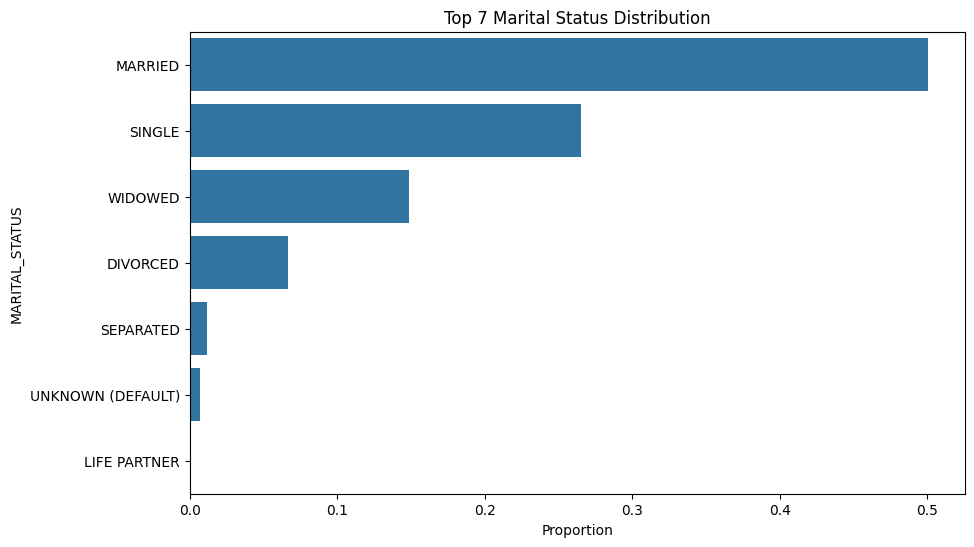

<ipython-input-6-3d06e6db7ca2>:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Proportion', y=column_name, data=df, ci=None)


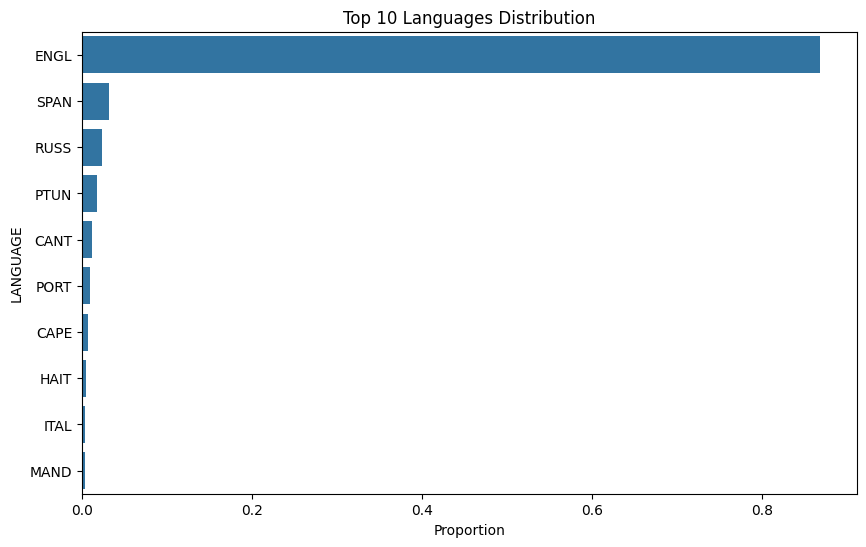

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(other_static_var_df['age_in_years'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age in Years')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Gender distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='GENDER', data=other_static_var_df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

ethnicity_counts = other_static_var_df['ETHNICITY'].value_counts(normalize=True).reset_index()
ethnicity_counts.columns = ['ETHNICITY', 'Proportion']
marital_status_counts = other_static_var_df['MARITAL_STATUS'].value_counts(normalize=True).reset_index()
marital_status_counts.columns = ['MARITAL_STATUS', 'Proportion']
language_counts = other_static_var_df['LANGUAGE'].value_counts(normalize=True).reset_index()
language_counts.columns = ['LANGUAGE', 'Proportion']

# Selecting the top 10 for each category (if applicable)
top_10_ethnicity = ethnicity_counts.head(10)
top_7_marital_status = marital_status_counts.head(7)
top_10_language = language_counts.head(10)

def plot_category_distribution(df, column_name, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Proportion', y=column_name, data=df, ci=None)
    plt.title(title)
    plt.xlabel('Proportion')
    plt.ylabel(column_name)
    plt.show()

# Plotting the distributions
plot_category_distribution(top_10_ethnicity, 'ETHNICITY', 'Top 10 Ethnicities Distribution')
plot_category_distribution(top_7_marital_status, 'MARITAL_STATUS', 'Top 7 Marital Status Distribution')
plot_category_distribution(top_10_language, 'LANGUAGE', 'Top 10 Languages Distribution')

# <ins> Preprocess Data and Feature Engineering

## Remove Admissions with more than 5 missing variables
* If any timestamp for an admission has more than 5 null values for variables then that admission(treatment plan) is removed for analysis per literature.

Codebase Link: https://github.com/Daponte29/Dynamic-Treatment-Recommendation-Supervised-Reinforcement-Learning-with-Recurrent-Neural-Network/blob/main/Remove_HADM_missing_variables_1.py

## Impute missing variables with KNN

Codebase Link: https://github.com/Daponte29/Dynamic-Treatment-Recommendation-Supervised-Reinforcement-Learning-with-Recurrent-Neural-Network/blob/main/Impute_missing_var_2.py

## Impute categorical using the statistical mode. One-hot-encode categorical features and create admission labels.

* Note: Normalization will be done independently on the training,validation, and test data after splitting to prevent Data Leakage

Codebase Link: https://github.com/Daponte29/Dynamic-Treatment-Recommendation-Supervised-Reinforcement-Learning-with-Recurrent-Neural-Network/blob/main/Pre_process_matrix_3.py

In [ ]:
df_admission_LABELS = pd.read_csv(os.path.join(RAW_DATA_DIR, "Final_Labels.csv"))

### Map top perscriptions to Third-LVL ATC Codes from API.

Codebase Link: https://github.com/Daponte29/Dynamic-Treatment-Recommendation-Supervised-Reinforcement-Learning-with-Recurrent-Neural-Network/blob/main/GET_ATC_CODES_API.py

In [ ]:
# Create a dictionary to store code map for ATC_CODES gotten from API
ATC_code_map = {}

# Enumerate over Chosen_ATC codes in third_lvl_atc_codes_df
for index, row in third_lvl_atc_codes_df.iterrows():
    # Extract Chosen_ATC code
    chosen_atc = row['Chosen_ATC']

    # Assign an index to the Chosen_ATC code
    ATC_code_map[chosen_atc] = index
print("ATC_CODE_MAP:",ATC_code_map)

ATC_CODE_MAP: {'B05C': 0, 'B05X': 1, 'C03C': 2, 'C07A': 3, 'S01A': 4, 'B01A': 5, 'A10A': 6, 'A02B': 7, 'A06A': 8, 'N02B': 9, 'N02A': 10, 'D11A': 11, 'A04A': 12, 'N05B': 13, 'R03A': 14, 'C05A': 15, 'C02D': 16, 'R01A': 17, 'N01A': 18, 'H04A': 19, 'A07A': 20, 'N05A': 21, 'A03F': 22, 'N05C': 23, 'C01B': 24, 'A12C': 25, 'D04A': 26, 'A01A': 27, 'C01C': 28, 'A02A': 29, 'C08D': 30, 'J01D': 31, 'N06A': 32, 'H02A': 33, 'J01C': 34, 'C09A': 35, 'C10A': 36, 'A11D': 37, 'V04C': 38, 'A11C': 39, 'C01A': 40, 'G01A': 41, 'C08C': 42, 'S01X': 43, 'S01B': 44, 'N03A': 45, 'B02B': 46, 'V03A': 47, 'J01E': 48, 'S01E': 49, 'B03A': 50, 'M03A': 51, 'L04A': 52, 'J05A': 53, 'S01F': 54, 'M04A': 55, 'C03D': 56, 'A07D': 57, 'R05C': 58, 'C03A': 59, 'G04C': 60, 'H03A': 61, 'J01X': 62, 'R02A': 63, 'A11E': 64, 'H01B': 65, 'C09B': 66, 'H01C': 67, 'J02A': 68, 'N07B': 69, 'C03B': 70, 'C01D': 71, 'A10B': 72, 'R03D': 73, 'N01B': 74, 'C09C': 75, 'B03X': 76, 'N06D': 77, 'B03B': 78, 'D10A': 79, 'M03B': 80, 'R05D': 81, 'R06A': 82,

## Build Necessary Matrices for Treatment Plan of Admissions Needed for The Actor-Critic ML Model Framework----------------------------------------------------------------

Codebase Link: https://github.com/Daponte29/Dynamic-Treatment-Recommendation-Supervised-Reinforcement-Learning-with-Recurrent-Neural-Network/blob/main/Pre_process_matrix_3.py

Check same HADM_ID in final Preprocessed Data

In [ ]:
# Extract the sets of HADM_ID values from each dataset
hadm_ids_time_series = set(time_series_matrices_filtered.keys())
hadm_ids_static = set(static_matrices_filtered.keys())
hadm_ids_labels = set(filtered_df_admission_LABELS['HADM_ID'])

# Check for any discrepancies
discrepancies = {
    'Time Series vs Static': hadm_ids_time_series - hadm_ids_static,
    'Time Series vs Labels': hadm_ids_time_series - hadm_ids_labels,
    'Static vs Labels': hadm_ids_static - hadm_ids_labels
}

# Print discrepancies, if any
for comparison, discrepancy_set in discrepancies.items():
    if discrepancy_set:
        print(f"Discrepancy between {comparison}: {discrepancy_set}")
    else:
        print(f"No discrepancies between {comparison}")

# If there are no discrepancies, it means all datasets have the same set of HADM_ID values


NameError: name 'time_series_matrices_filtered' is not defined

## Final Total Dataset Size and Number of Features

##END OF PROCESS RAW DATA______________________________________________________
### Final Matrices

In [ ]:
# Load Final Processed Matrices
# Note: These pickle files must be generated by running the preprocessing scripts first!

try:
    with open(os.path.join(RAW_DATA_DIR, 'treatment_matrices.pickle'), 'rb') as handle:
        treatment_matrices = pickle.load(handle)

    with open(os.path.join(RAW_DATA_DIR, 'time_series_matrices_filtered.pickle'), 'rb') as handle:
        time_series_matrices_filtered = pickle.load(handle)

    with open(os.path.join(RAW_DATA_DIR, 'static_matrices_filtered.pickle'), 'rb') as handle:
        static_matrices_filtered = pickle.load(handle)

    with open(os.path.join(RAW_DATA_DIR, 'diagnosis_matrices.pickle'), 'rb') as handle:
        diagnosis_matrices = pickle.load(handle)
        
    filtered_df_admission_LABELS = pd.read_pickle(os.path.join(RAW_DATA_DIR, 'filtered_df_admission_LABELS.pkl'))
    
    print("All matrices loaded successfully.")
except FileNotFoundError:
    print("Error: Processed pickle files not found in 'data/'. Please run scripts/Pre_process_matrix_3.py first.")

In [ ]:
# Extract the sets of HADM_ID values from each dataset
hadm_ids_time_series = set(time_series_matrices_filtered.keys())
hadm_ids_static = set(static_matrices_filtered.keys())
hadm_ids_labels = set(filtered_df_admission_LABELS['HADM_ID'])

# Check for any discrepancies
discrepancies = {
    'Time Series vs Static': hadm_ids_time_series - hadm_ids_static,
    'Time Series vs Labels': hadm_ids_time_series - hadm_ids_labels,
    'Static vs Labels': hadm_ids_static - hadm_ids_labels
}

# Print discrepancies, if any
for comparison, discrepancy_set in discrepancies.items():
    if discrepancy_set:
        print(f"Discrepancy between {comparison}: {discrepancy_set}")
    else:
        print(f"No discrepancies between {comparison}")

# If there are no discrepancies, it means all datasets have the same set of HADM_ID values

No discrepancies between Time Series vs Static
No discrepancies between Time Series vs Labels
No discrepancies between Static vs Labels


## Final Total Dataset Size and Number of Features *

In [ ]:
# Size of treatment matrices
treatment_matrix_size = treatment_matrices[list(treatment_matrices.keys())[0]].shape
num_treatment_features = treatment_matrix_size[1]
print("Number of Treatment Patient Features:", num_treatment_features)

# Size of time series matrices
time_series_matrix_size = time_series_matrices_filtered[list(time_series_matrices_filtered.keys())[0]].shape
num_time_series_features = time_series_matrix_size[1]
print("Number of Time Series Patient Admission Features:", num_time_series_features)

# Size of static matrices
static_matrix_value = next(iter(static_matrices_filtered.values()))
num_static_features = len(static_matrix_value)
print("Number of Static Patient Admission Features:", num_static_features)

# Size of diagnosis matrices
diagnosis_matrix_value = next(iter(diagnosis_matrices.values()))
num_diagnosis_features = len(diagnosis_matrix_value)
print("Number of Diagnosis Patient Admission Features:", num_diagnosis_features)

# Number of unique admissions in admission labels
num_admissions = len(filtered_df_admission_LABELS)
print("Number of Patient Unique Admissions or Total Dataset Size:", num_admissions)


Number of Treatment Patient Features: 92
Number of Time Series Patient Admission Features: 15
Number of Static Patient Admission Features: 6
Number of Diagnosis Patient Admission Features: 2000
Number of Patient Unique Admissions or Total Dataset Size: 28332


In [ ]:
def align_and_filter_data(action, lab, demo, label, diag):
    """
    Intersects the keys (HADM_IDs) across all data dictionaries to ensure alignment.
    Also computes a dense reward signal based on the final outcome.
    
    Args:
        action (dict): Treatment/Action matrices.
        lab (dict): Time-series lab results.
        demo (dict): Static demographic features.
        label (dict or pd.DataFrame): Outcome labels (Mortality).
        diag (dict): Diagnosis codes.
        
    Returns:
        tuple: (filtered_action, filtered_lab, filtered_demo, filtered_label, filtered_diag, generated_rewards)
    """
    # Standardize label input to dict if it's a DataFrame
    if not isinstance(label, dict):
        label = pd.Series(label.LABEL.values, index=label.HADM_ID).to_dict()

    # Find common HADM_IDs across all data sources
    hadm_set = set(action.keys()).intersection(
        set(lab.keys()),
        set(demo.keys()),
        set(label.keys()),
        set(diag.keys())
    )
    
    print(f"Aligning data... Original count: {len(action)}, Intersection count: {len(hadm_set)}")

    # Helper function to filter and sort dictionary by keys
    def filter_dict(d, keys):
        return dict(sorted({k: d[k] for k in keys if k in d}.items()))

    # Filter all dictionaries
    action = filter_dict(action, hadm_set)
    lab = filter_dict(lab, hadm_set)
    demo = filter_dict(demo, hadm_set)
    label = filter_dict(label, hadm_set)
    diag = filter_dict(diag, hadm_set)

    # -------------------------------------------------------------------------
    # Reward Shaping Logic
    # -------------------------------------------------------------------------
    # We assign a dense reward for each time step based of the final outcome.
    # If the patient dies (label=1), we penalize every step with -10.
    # If the patient survives (label=0), we reward every step with +10.
    # This guides the RL agent to value actions that lead to survival.
    reward = {}
    for id, actions_list in action.items():
        if label[id] == 1:
            reward[id] = [-10.0] * (len(actions_list))
        elif label[id] == 0:
            reward[id] = [10.0] * (len(actions_list))
        else:
            reward[id] = [0.0] * len(actions_list)

    return action, lab, demo, label, diag, reward

# Perform alignment
filtered_actions, filtered_lab, filtered_demo, filtered_label, filtered_diag, filtered_reward = align_and_filter_data(
    treatment_matrices, 
    time_series_matrices_filtered, 
    static_matrices_filtered, 
    filtered_df_admission_LABELS, 
    diagnosis_matrices
)

print("Data alignment complete.")
print(f"Final dataset size: {len(filtered_actions)} patients")

In [ ]:
#handcode
for k, v in lab.items():
    if len(v) > len(action[k]):
        lab[k] = v[:len(action[k])]
    elif len(v) < len(action[k]):
        zeros_to_add = np.zeros((len(action[k]) - len(v), v.shape[1]))
        lab[k] = np.concatenate((zeros_to_add,v ), axis=0)


In [ ]:
filtered_actions = {k: v[-8:] for k, v in action.items() if v.shape[0] > 8} #timestamp=8
filtered_lab={k:lab[k][-8:] for k in filtered_actions.keys()}
filtered_demo={k:demo[k] for k in filtered_actions.keys()}
filtered_label={k:label[k] for k in filtered_actions.keys()}
filtered_diag={k:diag[k] for k in filtered_actions.keys()}
filtered_reward={k:reward[k][-8:] for k in filtered_actions.keys()}

## Dataset Class

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import torch
import numpy as np

class MedicalDataset(Dataset):
    """
    Custom Dataset for Medical Treatment Recommendation.
    
    Args:
        disease_dic (dict): Dictionary mapping admission IDs to disease codes.
        demo_dic (dict): Dictionary mapping admission IDs to demographic features.
        lab_result (dict): Dictionary mapping admission IDs to laboratory results (time-series).
        actions (dict): Dictionary mapping admission IDs to medication actions (time-series).
        rewards (dict): Dictionary mapping admission IDs to rewards (time-series).
        label (dict): Dictionary mapping admission IDs to outcome labels (e.g., mortality).
    """
    def __init__(self, disease_dic, demo_dic, lab_result, actions, rewards, label):
        self.dones = {}
        # Create 'done' flags: 0 for all steps except the last one, which is 1.
        for id, actions_list in actions.items():
            self.dones[id] = [0] * (len(actions_list) - 1) + [1]
        
        self.dones = list(self.dones.values())
        self.diseases = list(disease_dic.values())
        self.demos = list(demo_dic.values())
        self.states = list(lab_result.values())
        
        if isinstance(actions, dict):
            self.actions = list(actions.values())
        else:
            self.actions = actions
            
        self.rewards = list(rewards.values())

        # Create 'next_states' by shifting states by one time step
        # The last state transitions to a zero-vector state (terminal state)
        self.new_states = self.states[1:] + [[0] * len(self.states[0])]

    def __len__(self):
        return len(self.demos)

    def __getitem__(self, idx):
        """
        Returns a single sample from the dataset.
        """
        diseases = self.diseases[idx]
        actions = self.actions[idx]
        rewards = self.rewards[idx]
        new_states = self.new_states[idx]
        demos = self.demos[idx]
        states = self.states[idx]
        dones = self.dones[idx]

        return states, actions, rewards, new_states, dones, diseases, demos


def my_collate_fn(batch):
    """
    Custom collate function to handle variable-length sequences in the batch.
    
    Args:
        batch (list): List of samples fetched from the dataset.
        
    Returns:
        Tuple of tensors: (states, actions, rewards, next_states, dones, diseases, demos)
    """
    states, actions, rewards, new_states, dones, diseases, demos = zip(*batch)

    # Convert lists to tensors and stack them
    # Note: Assuming states and actions are already uniform or processed to be stackable
    states = torch.stack([torch.tensor(s) for s in states])
    actions = torch.stack([torch.tensor(a) for a in actions])
    
    # For rewards and dones, they are variable length sequences, so we pad them
    rewards = [torch.tensor(r) for r in rewards]
    dones = [torch.tensor(d) for d in dones]

    # Stack diseases and demographics
    diseases = torch.stack([torch.tensor(d) for d in diseases])
    demos = torch.stack([torch.tensor(d) for d in demos])

    # Process new_states (next states)
    # Logic: take the first N-1 timestamps and append a zero timestamp at the end
    processed_new_states = []
    for s in states:
        # Assuming we want to shift the collected state 's' to create the next state
        # Here we take everything up to the last timestamp and append a zero vector
        # This simulates the transition to the next state, with the final state leading to a terminal zero state
        new_state = s[:-1] 
        zero_timestamp = torch.zeros_like(s[0]) 
        new_state_with_zero = torch.cat((new_state, zero_timestamp.unsqueeze(0)), dim=0)
        processed_new_states.append(new_state_with_zero)

    processed_new_states = torch.stack(processed_new_states)

    # Return padded sequences where necessary (batch_first=True)
    return (states, 
            actions, 
            pad_sequence(rewards, batch_first=True), 
            processed_new_states, 
            pad_sequence(dones, batch_first=True), 
            diseases, 
            demos)

# Initialize Dataset and Splits
# Note: Assuming filtered_* variables are available from previous cells
try:
    data = MedicalDataset(filtered_diag, filtered_demo, filtered_lab, filtered_actions, filtered_reward, filtered_label)
    
    # Split dataset into Train (80%), Test (10%), Validation (10%)
    train_size = int(0.8 * len(data))
    test_size = int(0.1 * len(data))
    valid_size = len(data) - train_size - test_size
    
    train_data, test_data, valid_data = random_split(data, [train_size, test_size, valid_size], generator=torch.Generator().manual_seed(42))
    
    print(f"Dataset split: Train={len(train_data)}, Test={len(test_data)}, Valid={len(valid_data)}")
except NameError:
    print("Filtered data variables not found. Make sure to run data processing cells first.")

In [ ]:
#Normalize Splits  Need to do this for "Dataleakage" concerns due to timeseries problem
#train_data_normalized =

## Specific Collate Function for Data

### Load the DataLoader Pytorch data for train,test,validate

In [ ]:
BATCH_SIZE=64
train_loader=DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True,collate_fn=my_collate_fn)
test_loader=DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True,collate_fn=my_collate_fn)
valid_loader=DataLoader(dataset=valid_data, batch_size=BATCH_SIZE, shuffle=True,collate_fn=my_collate_fn)

## Model Summary

The developed model for medical decision-making comprises two primary components: an Actor Network and a Critic Network, designed to work in tandem to optimize treatment strategies based on medical data inputs.

### Model Architecture
- **Actor Network:** Utilizes a combination of LSTM, linear, and embedding layers to process laboratory results, demographic data, and disease information. It incorporates an LSTM layer with 180 hidden units to capture temporal dependencies in lab results, linear layers to process demographic data and disease embeddings, and uses a sigmoid activation function to generate action probabilities.
- **Critic Network:** Mirrors the Actor Network in its use of LSTM, linear, and embedding layers but includes an additional action input layer. This network assesses the value of the actions proposed by the Actor Network, guiding the actor towards more beneficial decisions.
- **Dimension Details:** Both networks operate on time-series data with 8 time stamps, reflecting the dynamic nature of medical treatment over time.

### Training Objectives
- **Loss Functions:** The Critic Network utilizes Mean Squared Error (MSE) for loss calculation, reflecting the deviation between expected and predicted Q-values. The Actor Network's loss is a combination of the negative mean of the Critic's assessments (encouraging actions with higher expected returns) and a supervised learning component using cross-entropy (guiding the actor towards specific desirable actions).
- **Optimizers:** Adam optimizer with learning rates of 0.001 for the Actor and 0.005 for the Critic, facilitating the gradient descent process.
- **Regularization Techniques:** Dropout is applied within both networks to prevent overfitting, ensuring the model's generalizability.

### Additional Considerations
- **Model Dynamics:** The model uses a soft update strategy for the target networks (both actor and critic), controlled by a parameter `TAU`, to gradually integrate the learned weights, stabilizing the learning process.
- **Evaluation Metrics:** Jaccard score and accuracy are used for model evaluation, measuring the similarity between the predicted and actual treatments and the correctness of the action predictions, respectively.

### Implementation Details
- The Actor and Critic networks are implemented as PyTorch classes, encapsulating the network architecture and forward propagation logic.
- Training and evaluation functions handle the iterative learning process and performance assessment, incorporating mechanisms for dynamic adjustment based on feedback from the Critic Network.
- Data loaders facilitate batch processing of time-series medical data, accommodating the complex structure of patient records.

### Model Training and Validation
- The model underwent iterative training with a focus on minimizing the Critic's loss while maximizing the Actor's effectiveness in proposing beneficial actions.
- Validation was conducted on a separate dataset, ensuring that the model's performance is robust and not merely reflective of the training data characteristics.

This model represents a sophisticated approach to leveraging deep learning for decision-making in medical contexts, offering a nuanced understanding of patient data over time and promising avenues for personalized treatment strategies.


## Actor Network Class

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Hyperparameters
HIDDEN1_UNITS = 40
HIDDEN2_UNITS = 180

class ActorNetwork(nn.Module):
    """
    The Actor Network is responsible for selecting the best action (medication) given the current state.
    It takes patient demographics, disease codes, and lab test results as input.
    """
    def __init__(self, TAU, time_stamp, med_size, lab_size, demo_size, di_size):
        super(ActorNetwork, self).__init__()
        self.TAU = TAU
        self.time_stamp = time_stamp
        self.med_size = med_size
        self.lab_size = lab_size
        self.demo_size = demo_size
        self.di_size = di_size

        # --- Network Layers ---
        # 1. Process Lab Tests (Time Series) using LSTM
        # Input: (batch_size, seq_len, lab_size) -> Output: (batch_size, seq_len, hidden2_units)
        self.lstm = nn.LSTM(input_size=lab_size, hidden_size=HIDDEN2_UNITS, batch_first=True)
        
        # 2. Process Demographics (Static Features)
        # Input: (batch_size, demo_size) -> Output: (batch_size, hidden1_units)
        self.demo_dense = nn.Linear(demo_size, HIDDEN1_UNITS)
        
        # 3. Process Disease Codes (Categorical/Embedding)
        # Input: (batch_size, di_size) -> Output: (batch_size, di_size, hidden1_units)
        self.disease_embedding = nn.Embedding(2001, HIDDEN1_UNITS, padding_idx=0)
        
        # 4. Final Output Layer
        # Combines LSTM output + Disease features + Demographic features -> Action probabilities
        self.dense_time_distributed = nn.Linear(HIDDEN2_UNITS + HIDDEN1_UNITS*2, med_size)
        self.output_activation = nn.Sigmoid()

    def forward(self, lab_test, disease, demo):
        # --- Demo Processing ---
        demo = demo.float()
        # Learnable PReLU activation
        weight_prelu = torch.tensor([0.25]).to(demo.device) # Correct device usage
        demo = F.prelu(self.demo_dense(demo), weight=weight_prelu)
        # Expand static demo features across time steps
        demo = demo.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Disease Processing ---
        # Get embeddings for diseases
        disease_emb = self.disease_embedding(disease.long()) 
        # Average embeddings across disease codes (if multiple per admission)
        disease_avg = self.avg_emb(disease_emb)
        # Expand static disease features across time steps
        disease_repeated = disease_avg.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Lab Test Processing (LSTM) ---
        lstm_out, _ = self.lstm(lab_test)
        
        # --- Concatenation ---
        # Combine all features along the last dimension (channels)
        combined = torch.cat([lstm_out, disease_repeated, demo], dim=-1) # Concatenate along feature dimension
        
        # --- Output ---
        output = self.dense_time_distributed(combined)
        output = self.output_activation(output)
        return output

    @staticmethod
    def avg_emb(emb, mask=None):
        """
        Computes the average embedding, handling padding if a mask is provided.
        """
        if mask is None:
            return torch.mean(emb, dim=1)
        else:
            mask = mask.float().unsqueeze(-1)
            emb_masked = emb * mask
            sum_emb = torch.sum(emb_masked, dim=1)
            sum_mask = torch.clamp(torch.sum(mask, dim=1), min=1e-9)
            avg_emb = sum_emb / sum_mask
            return avg_emb

    def train_model(self, states, disease, demos, label, action_grads, sw):
        # Helper method for training if needed
        self.train()
        self.optimizer.zero_grad()
        outputs = self(states, disease, demos)
        loss = self.criterion(outputs, label)
        loss.backward()
        self.optimizer.step()

    def target_train(self, target_model):
        """
        Soft update for target network (used in RL stability).
        target_param = tau * current_param + (1 - tau) * target_param
        """
        for target_param, param in zip(target_model.parameters(), self.parameters()):
            target_param.data.copy_(self.TAU * param.data + (1.0 - self.TAU) * target_param.data)

## Critic Netowork Class

In [ ]:
class CriticNetwork(nn.Module):
    """
    The Critic Network evaluates the 'value' or 'quality' of an action given a state.
    It takes the state (demographics, disease, lab tests) AND the action (medication) as input.
    """
    def __init__(self, TAU, time_stamp, med_size, lab_size, demo_size, di_size):
        super(CriticNetwork, self).__init__()
        self.TAU = TAU
        self.time_stamp = time_stamp
        self.med_size = med_size
        self.lab_size = lab_size
        self.demo_size = demo_size
        self.di_size = di_size

        # --- Network Layers ---
        self.dropout_lab_test = nn.Dropout(p=0.5)
        self.demo_dense = nn.Linear(demo_size, HIDDEN1_UNITS)
        self.demo_prelu = nn.PReLU()
        self.disease_embedding = nn.Embedding(2001, HIDDEN1_UNITS, padding_idx=0)
        self.lstm = nn.LSTM(lab_size, HIDDEN2_UNITS, batch_first=True)
        
        # Action Input Processing
        # The critic combines state features + action features to predict Q-value
        self.action_dense_time_distributed = nn.Linear(med_size, HIDDEN2_UNITS + 2*HIDDEN1_UNITS)
        self.final_dense_time_distributed = nn.Linear(HIDDEN2_UNITS + 2*HIDDEN1_UNITS, 1)

    def forward(self, lab_test, action, disease, demo):
        # --- Demo Processing ---
        demo = demo.float()
        demo = self.demo_prelu(self.demo_dense(demo))
        demo_repeated = demo.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Disease Processing ---
        # Get embeddings for disease codes
        disease_emb = self.disease_embedding(disease.long())
        # Average embeddings across diagnoses
        disease_avg = self.avg_emb(disease_emb)
        disease_repeated = disease_avg.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Lab Test Processing (LSTM) ---
        lab_test = self.dropout_lab_test(lab_test)
        lstm_out, _ = self.lstm(lab_test)
        
        # --- Action Processing ---
        # Project action space to match hidden state dimensions
        action_transformed = self.action_dense_time_distributed(action)
        
        # --- Value Estimation ---
        # Concatenate state features (LSTM + Disease + Demo)
        # Note: Code had `dim=2` which is (batch, time, feature). Correct.
        combined = torch.cat([lstm_out, disease_repeated, demo_repeated], dim=2)

        # Merge State + Action
        # This is the core "Q-function" logic: Q(s, a)
        h2 = combined + action_transformed
        
        # Final linear layer to predict value
        output = self.final_dense_time_distributed(h2)
        return output

    @staticmethod
    def avg_emb(emb, mask=None):
        """
        Computes average embedding.
        """
        if mask is None:
            return torch.mean(emb, dim=1)
        else:
            mask = mask.float().unsqueeze(-1)
            emb_masked = emb * mask
            sum_emb = torch.sum(emb_masked, dim=1)
            sum_mask = torch.clamp(torch.sum(mask, dim=1), min=1e-9)
            avg_emb = sum_emb / sum_mask
            return avg_emb

## Basic (Long Short-Term Memory) LSTM RNN-type Model for Comparison

In [ ]:
class Basic_LSTM(nn.Module):
    """
    A simpler RNN-based model (LSTM) used as a baseline for comparison.
    It takes the same inputs as the Actor (State) but uses a standard supervised learning loss.
    """
    def __init__(self, TAU, time_stamp, med_size, lab_size, demo_size, di_size):
        super(Basic_LSTM, self).__init__()
        self.TAU = TAU
        self.time_stamp = time_stamp
        self.med_size = med_size
        self.lab_size = lab_size
        self.demo_size = demo_size
        self.di_size = di_size

        # --- Network Layers ---
        self.lstm = nn.LSTM(input_size=lab_size, hidden_size=HIDDEN2_UNITS, batch_first=True)
        self.demo_dense = nn.Linear(demo_size, HIDDEN1_UNITS) # M2
        self.disease_dense = nn.Linear(di_size, HIDDEN1_UNITS) # M1
        
        # PReLU initial weights
        self.prelu_weight = torch.tensor([0.25])
        
        self.dense_time_distributed = nn.Linear(HIDDEN2_UNITS + HIDDEN1_UNITS*2, med_size)
        self.output_activation = nn.Sigmoid()

    def forward(self, lab_test, disease, demo):
        # --- Demo Processing ---
        demo = demo.float()
        # Note: Using functional PReLU with manual weight
        # Ensure weight is on the same device as input
        weight = self.prelu_weight.to(demo.device)
        demo = F.prelu(self.demo_dense(demo), weight=weight)
        demo_repeated = demo.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Disease Processing ---
        disease = disease.float()
        disease = F.prelu(self.disease_dense(disease), weight=weight)
        disease_repeated = disease.unsqueeze(1).repeat(1, self.time_stamp, 1)

        # --- Lab Test Processing (LSTM) ---
        lstm_out, _ = self.lstm(lab_test)
        
        # --- Concatenation ---
        combined = torch.cat([lstm_out, disease_repeated, demo_repeated], dim=-1) 
        
        # --- Output ---
        output = self.dense_time_distributed(combined)
        output = self.output_activation(output)
        return output

    @staticmethod
    def avg_emb(emb, mask=None):
        if mask is None:
            return torch.mean(emb, dim=1)
        else:
            mask = mask.float().unsqueeze(-1)
            emb_masked = emb * mask
            sum_emb = torch.sum(emb_masked, dim=1)
            sum_mask = torch.clamp(torch.sum(mask, dim=1), min=1e-9)
            avg_emb = sum_emb / sum_mask
            return avg_emb

## Train Block for Actor-Critic SRL-RNN Model

In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import jaccard_score, accuracy_score

# --- Tracking Metrics ---
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def soft_update(target, source, tau):
    """
    Soft update model parameters:
    target_param = (tau * source_param) + ((1 - tau) * target_param)
    This stabilizes training by slowly updating the target network.
    """
    for target_param, param in zip(target.parameters(), source.parameters()):
        target_param.data.copy_(target_param.data * (1.0 - tau) + param.data * tau)

# --- Training Logic ---

def train(actor, critic, target_actor, target_critic, actor_optimizer, critic_optimizer, dataloader, gamma=0.99, tau=0.001, epsilon=0.5):
    """
    Trains the Actor-Critic model for one epoch using DDPG-style updates.
    """
    actor.train()
    critic.train()
    target_actor.eval() # Target networks are only used for inference (evaluation) within training
    target_critic.eval()

    total_actor_loss = 0.0
    total_critic_loss = 0.0
    all_preds = []
    all_targets = []
    max_reward = 30
    rl_loss = 0.0
    sl_loss = 0.0
    
    for states, actions, rewards, next_states, dones, diseases, demos in dataloader:
        # Move data to GPU if available
        # Call .to(device) here if using CUDA
        states = states.float()
        actions = actions.float()
        next_states = next_states.float()
        demos = demos.float()
        
        # --- 1. Train the Critic ---
        with torch.no_grad():
            # Use TARGET Actor to predict next action
            # This separates the target from the current policy being updated
            next_actions = target_actor(next_states, diseases, demos)
            
            # Use TARGET Critic to evaluate next state-action pair
            next_q_values = target_critic(next_states, next_actions, diseases, demos)
            
            rewards = rewards.unsqueeze(-1)
            dones = dones.unsqueeze(-1)
            
            # Bellman Equation: Q_target = Reward + Gamma * Q_next
            expected_q_values = rewards + gamma * (1 - dones) * next_q_values
            expected_q_values = torch.clamp(expected_q_values, -max_reward, max_reward)

        # Optimize Critic
        # Critic predicts value using CURRENT networks
        current_q_values = critic(states, actions, diseases, demos)
        
        # Critic Loss: MSE between Current Prediction and Target Value
        critic_loss = F.mse_loss(current_q_values, expected_q_values)
        
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()
        
        total_critic_loss += critic_loss.item()
        
        # --- 2. Train the Actor ---
        # Actor predicts action probabilities
        predicted_actions = actor(states, diseases, demos)
        
        # RL Loss: Maximize Critic's Q-value (Minimize Negative Q-value)
        # We want the Actor to choose actions that the Critic thinks are high value
        # Note: We freeze the Critic here (no backprop through critic) effectively, though pytorch handles this if we don't call backward on critic
        actor_loss = (-critic(states, predicted_actions, diseases, demos)).mean()
        
        # Supervised Loss: Imitate Doctor's action
        supervised_loss_function = nn.BCELoss()
        supervised_loss = supervised_loss_function(predicted_actions, actions) 
        
        # Combined Loss
        total_loss = (1 - epsilon) * actor_loss + epsilon * supervised_loss 
        
        actor_optimizer.zero_grad()
        total_loss.backward()
        actor_optimizer.step()
        
        total_actor_loss += total_loss.item()
        rl_loss += actor_loss.item()
        sl_loss += supervised_loss.item()

        # --- 3. Update Target Networks ---
        # Slowly move Target parameters towards Current parameters
        soft_update(target_critic, critic, tau)
        soft_update(target_actor, actor, tau)
        
        # --- 4. Collect Metrics ---
        preds = (predicted_actions > 0.5).float() 
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(actions.detach().cpu().numpy())

    avg_actor_loss = total_actor_loss / len(dataloader)
    avg_critic_loss = total_critic_loss / len(dataloader)
    avg_rl_loss = rl_loss / len(dataloader)
    avg_sl_loss = sl_loss / len(dataloader)
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    avg_jaccard = jaccard_score(all_targets, all_preds, average='samples')
    
    return avg_actor_loss, avg_critic_loss, avg_jaccard, avg_rl_loss, avg_sl_loss


def evaluate(actor, critic, dataloader, epsilon=0.9):
    actor.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    supervised_loss_function = nn.BCELoss()
    
    with torch.no_grad(): 
        for states, actions, rewards, next_states, dones, diseases, demos in dataloader:
            states = states.float()
            diseases = diseases.float()
            demos = demos.float()
            actions = actions.float()
            
            predicted_actions = actor(states, diseases, demos).float()
            
            loss = supervised_loss_function(predicted_actions, actions)
            total_loss += loss.item()
            
            preds = (predicted_actions > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(actions.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    avg_loss = total_loss / len(dataloader)
    
    jaccard = jaccard_score(all_targets, all_preds, average='samples')  
    
    accuracies = [accuracy_score(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
    accuracy = np.mean(accuracies)
    
    return avg_loss, jaccard, accuracy, all_preds, all_targets

## Train Block for Basic LSTM RNN-Type Model

In [ ]:
def BL_train(model, optimizer, dataloader):
    """
    Trains the Basic LSTM (Baseline) model for one epoch.
    This uses purely Supervised Learning (SL) with Binary Cross Entropy Loss.
    
    Args:
        model: The Basic_LSTM model instance.
        optimizer: The optimizer (e.g., Adam).
        dataloader: DataLoader for training data.
        
    Returns:
        tuple: (avg_loss, avg_jaccard, avg_accuracy)
    """
    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    loss_function = nn.BCELoss() # Binary Cross Entropy for multi-label classification
    
    for states, actions, rewards, next_states, dones, diseases, demos in dataloader:
        states = states.float().to(device)
        actions = actions.float().to(device)
        diseases = diseases.float().to(device) 
        demos = demos.float().to(device)
        
        # Forward Pass
        predicted_actions = model(states, diseases, demos)
        
        # Calculate Loss (Difference between predicted probabilities and actual doctor actions)
        loss = loss_function(predicted_actions, actions)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Metrics: We use a threshold of 0.5 to determine binary predictions
        preds = (predicted_actions > 0.5).float()
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(actions.detach().cpu().numpy())

    # Aggregate metrics over the epoch
    avg_loss = total_loss / len(dataloader)
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    avg_jaccard = jaccard_score(all_targets, all_preds, average='samples')
    
    # Calculate accuracy for each sample then average
    accuracies = [accuracy_score(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
    avg_accuracy = np.mean(accuracies)
    
    return avg_loss, avg_jaccard, avg_accuracy


def BL_evaluate(model, dataloader):
    """
    Evaluates the Basic LSTM model on validation/test data.
    
    Args:
        model: The trained Basic_LSTM model.
        dataloader: DataLoader for validation/test data.
        
    Returns:
        tuple: (avg_loss, avg_jaccard, avg_accuracy, all_preds, all_targets)
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    loss_function = nn.BCELoss()
    
    with torch.no_grad(): 
        for states, actions, rewards, next_states, dones, diseases, demos in dataloader:
            states = states.float().to(device)
            actions = actions.float().to(device)
            diseases = diseases.float().to(device)
            demos = demos.float().to(device)
            
            predicted_actions = model(states, diseases, demos)
            
            loss = loss_function(predicted_actions, actions)
            total_loss += loss.item()
            
            preds = (predicted_actions > 0.5).float()
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(actions.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    avg_jaccard = jaccard_score(all_targets, all_preds, average='samples')  
    
    accuracies = [accuracy_score(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
    avg_accuracy = np.mean(accuracies)
    
    return avg_loss, avg_jaccard, avg_accuracy, all_preds, all_targets

In [ ]:
USE_CUDA = False  # Set 'True' if you want to use GPU


device = torch.device("cuda" if torch.cuda.is_available() and USE_CUDA else "cpu")
torch.manual_seed(1)
if device.type == "cuda":
	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = False


## Start Training of SRL-RNN Model

In [ ]:
# Define path to save models
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)  # Ensure folder exists
actor_model_path = os.path.join(model_dir, 'best_actor.pth')
critic_model_path = os.path.join(model_dir, 'best_critic.pth')
target_actor_model_path = os.path.join(model_dir, 'best_target_actor.pth')
target_critic_model_path = os.path.join(model_dir, 'best_targetcritic.pth')

NUM_EPOCHS = 30
BATCH_SIZE = 32
TAU = 0.001

# Model initialization
# Initialize with appropriate parameters based on data shape
actor = ActorNetwork(TAU, time_stamp=8, 
                     med_size=train_data[0][1].shape[1], 
                     lab_size=train_data[0][0].shape[1], 
                     demo_size=train_data[0][6].shape[0], 
                     di_size=train_data[0][5].shape[0])

critic = CriticNetwork(TAU, time_stamp=8, 
                       med_size=train_data[0][1].shape[1], 
                       lab_size=train_data[0][0].shape[1], 
                       demo_size=train_data[0][6].shape[0], 
                       di_size=train_data[0][5].shape[0])

target_actor = ActorNetwork(TAU, time_stamp=8, 
                            med_size=train_data[0][1].shape[1], 
                            lab_size=train_data[0][0].shape[1], 
                            demo_size=train_data[0][6].shape[0], 
                            di_size=train_data[0][5].shape[0])

target_critic = CriticNetwork(TAU, time_stamp=8, 
                              med_size=train_data[0][1].shape[1], 
                              lab_size=train_data[0][0].shape[1], 
                              demo_size=train_data[0][6].shape[0], 
                              di_size=train_data[0][5].shape[0])

target_actor.load_state_dict(actor.state_dict())
target_critic.load_state_dict(critic.state_dict())

actor.to(device)
critic.to(device)
target_actor.to(device)
target_critic.to(device)

actor_optimizer = optim.Adam(actor.parameters(), lr=0.001)
critic_optimizer = optim.Adam(critic.parameters(), lr=0.005)

best_jaccard = 0.0
train_actor_losses, train_critic_losses, train_jaccards = [], [], []
valid_losses, valid_accuracies, valid_jaccards = [], [], []
avg_rl_losses, avg_sl_losses = [], []

for epoch in range(NUM_EPOCHS):
    train_actor_loss, train_critic_loss, train_jaccard, avg_rl_loss, avg_sl_loss = train(
        actor, critic, target_actor, target_critic, actor_optimizer, critic_optimizer, train_loader, gamma=0.99, tau=0.001
    )
    valid_loss, valid_jaccard, valid_accuracy, all_preds, all_targets = evaluate(actor, critic, valid_loader)

    train_actor_losses.append(train_actor_loss)
    valid_losses.append(valid_loss)

    train_critic_losses.append(train_critic_loss)
    valid_accuracies.append(valid_accuracy)
    train_jaccards.append(train_jaccard)
    valid_jaccards.append(valid_jaccard)
    avg_rl_losses.append(avg_rl_loss)
    avg_sl_losses.append(avg_sl_loss)
    
    # Save the model that has the best accuracy (or other metric)
    is_best = valid_jaccard > best_jaccard
    if is_best:
        best_jaccard = valid_jaccard
        torch.save(actor, actor_model_path, _use_new_zipfile_serialization=False)
        torch.save(critic, critic_model_path, _use_new_zipfile_serialization=False)
        torch.save(target_actor, target_actor_model_path, _use_new_zipfile_serialization=False)
        torch.save(target_critic, target_critic_model_path, _use_new_zipfile_serialization=False)

best_actor = torch.load(actor_model_path)

/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type ActorNetwork. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type CriticNetwork. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type ActorNetwork. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type CriticNetwork. It won't be checked for correctness upon loading.
  warnings.w

## Start Training of Basic LSTM RNN-Type Model

In [ ]:
# 1. Initialize the Basic LSTM Model
# - Input dimensions match the data features (medications, labs, demographics, diseases)
# - Hidden size is a hyperparameter (e.g., 64)
# - Output size is the number of medications (multi-label classification)
BL_model = Basic_LSTM(
    med_size=train_data[0][1].shape[1], 
    lab_size=train_data[0][0].shape[1], 
    demo_size=train_data[0][6].shape[0], 
    di_size=train_data[0][5].shape[0], 
    hidden_size=64
)

BL_model.to(device) # Move model to GPU if available

# 2. Define Optimizer
# Adam is a standard optimizer for deep learning.
BL_optimizer = optim.Adam(BL_model.parameters(), lr=0.001)

# 3. Training Loop
# Unlike RL, here we just minimize the difference between predicted actions and doctor's actions.
NUM_EPOCHS_BL = 30
best_bl_jaccard = 0.0

# Lists to store metrics for plotting
BL_train_losses, BL_train_jaccards, BL_train_accuracies = [], [], []
BL_valid_losses, BL_valid_jaccards, BL_valid_accuracies = [], [], []

print("Starting Supervised Training for Basic LSTM...")

for epoch in range(NUM_EPOCHS_BL):
    # Train for one epoch
    train_loss, train_jaccard, train_accuracy = BL_train(BL_model, BL_optimizer, train_loader)
    
    # Evaluate on validation set
    valid_loss, valid_jaccard, valid_accuracy, _, _ = BL_evaluate(BL_model, valid_loader)
    
    # Store metrics
    BL_train_losses.append(train_loss)
    BL_train_jaccards.append(train_jaccard)
    BL_train_accuracies.append(train_accuracy)
    
    BL_valid_losses.append(valid_loss)
    BL_valid_jaccards.append(valid_jaccard)
    BL_valid_accuracies.append(valid_accuracy)
    
    # Save best model
    if valid_jaccard > best_bl_jaccard:
        best_bl_jaccard = valid_jaccard
        torch.save(BL_model, os.path.join(model_dir, 'best_BL.pth'))
        print(f"Epoch {epoch+1}: New Best Jaccard: {valid_jaccard:.4f}")
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_BL} - "
              f"Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}, "
              f"Train Jaccard: {train_jaccard:.4f}, Valid Jaccard: {valid_jaccard:.4f}")

print("Training Complete.")

/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type Basic_LSTM. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type Basic_LSTM. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type Basic_LSTM. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/usr/local/lib/python3.10/dist-packages/torch/serialization.py:662: UserWarning: Couldn't retrieve source code for container of type Basic_LSTM. It won't be checked for correctness upon loading.
  warnings.warn("Could

In [ ]:
for states, actions, rewards, next_states, dones, diseases, demos in train_loader:
  print(next_states.size())
  print(diseases.size())
  print(demos.size())
  break

torch.Size([64, 8, 15])
torch.Size([64, 2000])
torch.Size([64, 6])


In [ ]:
print(all_preds[1])
print(all_targets[1])
jaccard_score(all_targets[1],all_preds[1])

In [ ]:
sum(all_preds[1])

In [ ]:
intersection = np.logical_and(all_targets[1], all_preds[1])
union = np.logical_or(all_targets[1], all_preds[1])

intersection_size = np.sum(intersection)
union_size = np.sum(union)

print("Intersection size:", intersection_size)
print("Union size:", union_size)

In [ ]:
intersection

In [ ]:
train_actor_losses

## Result SRL-RNN Model

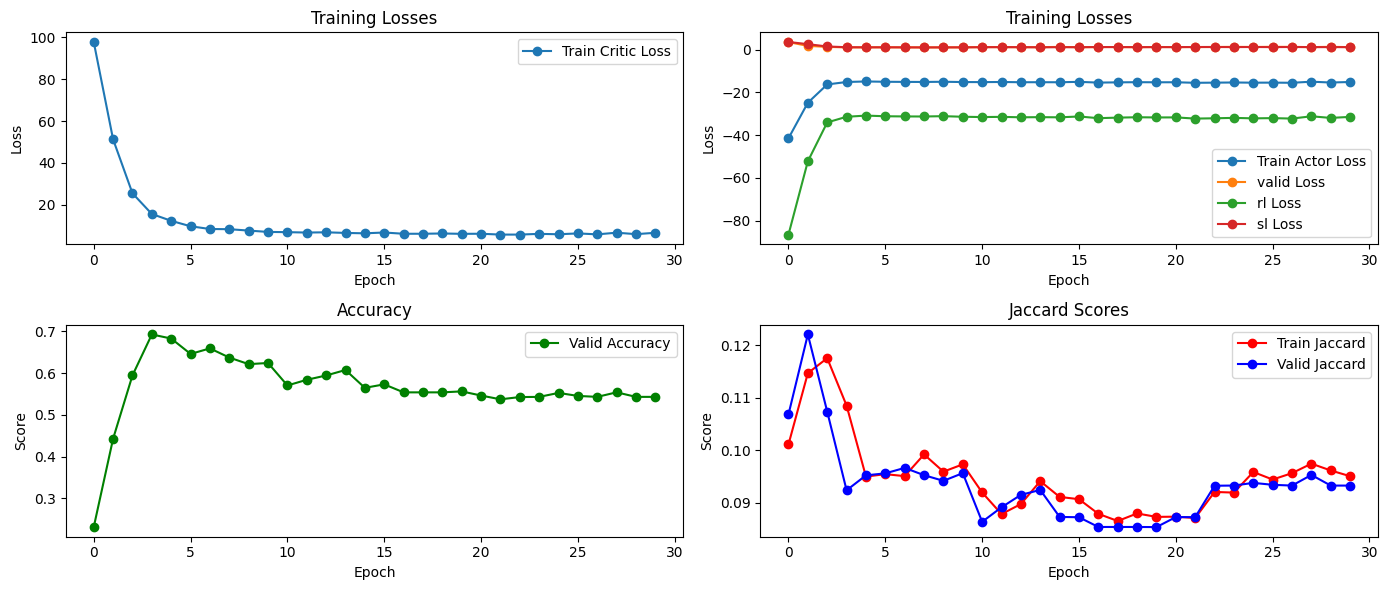

In [ ]:
import matplotlib.pyplot as plt

def plot_rl_metrics():
    """
    Plots the training metrics for the Actor-Critic (RL) model.
    """
    plt.figure(figsize=(14, 10))

    # 1. Critic Loss: Measures how well the Critic predicts the 'Value' (future reward)
    # Ideally, this should decrease over time as the Critic learns the environment.
    plt.subplot(2, 2, 1)
    plt.plot(train_critic_losses, label='Train Critic Loss', marker='o', color='orange')
    plt.title('Critic Loss (Value Estimation Error)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # 2. Actor Loss: This is usually negative Q-value.
    # We want to MAXIMIZE Q-value, so we MINIMIZE -Q.
    # This graph might fluctuate or go up/down, which is normal in RL.
    plt.subplot(2, 2, 2)
    plt.plot(train_actor_losses, label='Train Actor Loss (-Q Value)', marker='o', color='purple')
    plt.title('Actor Loss (Policy Optimization)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 3. Validation Accuracy: Simple matching of actions.
    plt.subplot(2, 2, 3)
    plt.plot(valid_accuracies, label='Valid Accuracy', marker='o', color='green')
    plt.title('Validation Accuracy (Subset Match)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 4. Jaccard Score: The most important metric for multi-label classification.
    # Intersection over Union of predicted drugs vs actual doctor drugs.
    plt.subplot(2, 2, 4)
    plt.plot(train_jaccards, label='Train Jaccard', marker='o', color='red')
    plt.plot(valid_jaccards, label='Valid Jaccard', marker='o', color='blue')
    plt.title('Jaccard Score (Intersection over Union)')
    plt.xlabel('Epoch')
    plt.ylabel('Score (0-1)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("Plotting Actor-Critic Training Results...")
plot_rl_metrics()

* It is clear that improvment is not seen or is worse after a short amount of epochs(around 4). This is partly due to the Actor loss function consisting of two terms that contain positive and negative values that result in the losses hovering around 0. The paper did not mention how to solve this issue in the Actor-Critic framework. The unexplained data preprocessing steps additionally contributes to these poor results.
* The ambigious reward function is also one factors cause this problem. We do not make sure what the situation that reward is 0 and the reward only produce at the final timestamp or all of time stamps.
* High accuracy and low Jaccard score can happen when the model accurately predicts the majority class but struggles with minority classes, especially in imbalanced datasets. Accuracy measures overall correctness, while the Jaccard score, which considers the intersection over union of predicted and true labels, penalizes for misclassification of minority classes, leading to a lower score despite high accuracy. Thus it follows the trend that the major issue in this replication can be seen from the innacurate explanation of preprocessing the data, leading to data quality issues.

## Result Basic LSTM RNN-Type Model

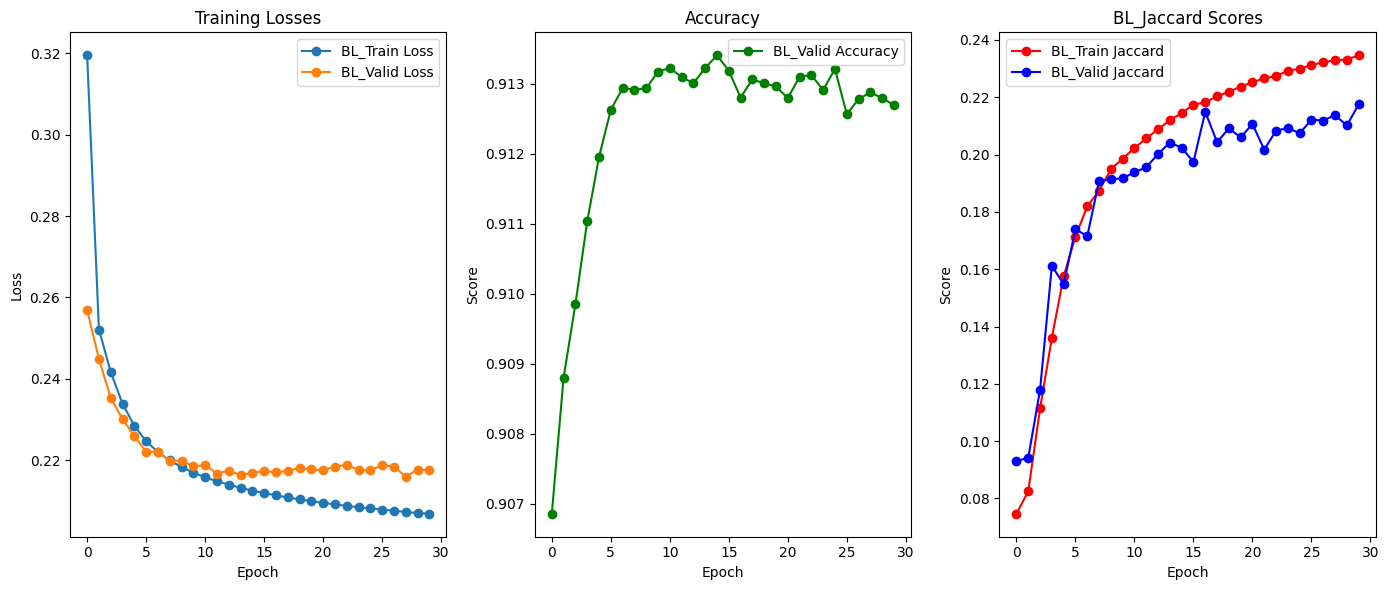

In [ ]:
def plot_lstm_metrics():
    """
    Plots the training metrics for the Basic LSTM (Supervised) model.
    """
    plt.figure(figsize=(14, 6))

    # 1. Training Loss (Binary Cross Entropy)
    # This should steadily decrease as it learns to mimic doctor's actions.
    plt.subplot(1, 3, 1)
    plt.plot(BL_train_losses, label='Train Loss', marker='o', color='red')
    plt.plot(BL_valid_losses, label='Valid Loss', marker='o', color='blue')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True)

    # 2. Validation Accuracy
    # Note: Accuracy for multi-label can be strict (exact set match) or subset match.
    # Here we are plotting subset (accuracy_score from sklearn).
    plt.subplot(1, 3, 2)
    plt.plot(BL_valid_accuracies, label='Valid Accuracy', marker='o', color='green')
    plt.title('Validation Accuracy (Subset Match)')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # 3. Jaccard Score
    # The gold standard for measuring overlap of predicted drug sets vs true sets.
    plt.subplot(1, 3, 3)
    plt.plot(BL_train_jaccards, label='Train Jaccard', marker='o', color='orange')
    plt.plot(BL_valid_jaccards, label='Valid Jaccard', marker='o', color='purple')
    plt.title('Jaccard Score (IoU)')
    plt.xlabel('Epoch')
    plt.ylabel('Score (0-1)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("Plotting Basic LSTM Training Results...")
plot_lstm_metrics()

* The Loss function in the Basic LSTM model shows a higher epoch(around 10) as opposed to the SRL-RNN model and a much higher accuracy and Jaccard Score are seen at the same epoch as SRL-RNN.
* That's may because the actor loss is combined by two part, one part is negative and another part is positive and they have different scaler. This evidence suggests again that data quality issues resulting from improper processing not explained in the literature. The negative loss function will cause model cannot learn well from data.

In [ ]:
"""
Final Evaluation on Test Set (RL Model)
"""
print("Evaluating best RL Actor on Test Set...")

# Ensure model is in eval mode
best_actor.eval()

# Use the evaluate function we defined earlier
# Note: passing 'critic' is required by signature but only used for loss calculation
test_loss, test_jaccard, test_accuracy, _, _ = evaluate(best_actor, critic, test_loader)

print(f"Test Set - RL Actor Jaccard Score: {test_jaccard:.4f}")
print(f"Test Set - RL Actor Accuracy: {test_accuracy:.4f}")

In [ ]:

jaccard

0.11823728571533411

In [ ]:
"""
Final Evaluation on Test Set (Basic LSTM Model)
"""
print("Evaluating best Basic LSTM on Test Set...")

# Load the best model saved during training
best_bl_path = os.path.join(model_dir, 'best_BL.pth')
if os.path.exists(best_bl_path):
    best_bl_model = torch.load(best_bl_path)
    best_bl_model.to(device)
    best_bl_model.eval()

    # Use the BL_evaluate function we defined earlier
    test_loss_bl, test_jaccard_bl, test_accuracy_bl, _, _ = BL_evaluate(best_bl_model, test_loader)

    print(f"Test Set - Basic LSTM Jaccard Score: {test_jaccard_bl:.4f}")
    print(f"Test Set - Basic LSTM Accuracy: {test_accuracy_bl:.4f}")
else:
    print("Best LSTM model not found. Ensure training cell ran successfully.")

In [ ]:
BL_jaccard

0.21502890516542683

We used accuracy and Jaccard score to measure if our dynamic treatment can fit doctors treatment. However the Jaccard results are poor not only for the SRL-RNN model but also the LSTM due to many ambiguous preprocessing steps from original paper that are also evident in the 'Issues' tab within the authors GitHub that depict other people trying to replicate this literature with similar issues and no responses from the author such as:  
  * How to deal with static admission variables(e.g calculate height and weight as there are many values such as start height, end height, etc.)
  * Which API and how to map thrid level ATC codes to the NDC medicaitons.
  * How to line up in correct time order for timestamps for time-series lab variables and NDC medications.
    * In some admission, the lab result and treatment are not start at first 24 hour after admission.
    * Additionally the paper used a fixed timestamp of 5 with no explanation how they transformed the medication and time-series timestamps to accomdate for this.



## Model comparison (Numerical)



### Final Jaccard Metrics all models



| Model  | Jaccard Score  | Jaccard Score in Paper |
|--------|--------|--------|
| SRL_RNN  | 0.118  | 0.563  |
| Basic_LSTM  | 0.215  | 0.512  |

#### The similar trend in slighly poorer results in Jaccard from SRL-RNN to basic LSTM model align with our replication results however the scores are much lower in our replication due to our hypothesis of data quality issues from innacurate descriptions of preprocessing steps, mainly on timestamp alignment between NDC medicaitons and laboratory time-series states of patients in an admission that we were forced to use our own ingenuity to preprocess.

In [ ]:
# compare you model with others
# you don't need to re-run all other experiments, instead, you can directly refer the metrics/numbers in the paper

# Discussion

In this section,you should discuss your work and make future plan. The discussion should address the following questions:
  * Make assessment that the paper is reproducible or not.
  * Explain why it is not reproducible if your results are kind negative.
  * Describe “What was easy” and “What was difficult” during the reproduction.
  * Make suggestions to the author or other reproducers on how to improve the reproducibility.
  * What will you do in next phase.
* This paper is not reproducible. Since there are too many ambiguous points from original paper in handling the Critic Loss function summation terms resulting to close to 0 values for the critic loss functon(summation of positive and negative terms by the RL and SL terms) and data preprocessing steps evident in past replicators experiencing similar issues relating mostly to timestamp lineup of NDC medicationan actions and time-series patient variables. For example in many admissions, the lab result and treatment do not start at first 24 hour after admition and how to handle these discrepencies were not clearly discussed in the literature which we believe is the major issue for data quality for the models.

    * Under the issues tab from this paper's Github, other people asked how to process data and if anybody can run authors' code. The authors did not respond to any of these inquiries.

    * The difficult part of this replication is how to process those data and how to applied loss function inside actor and critics network but also apply another loss function in Pytorch.

    * The easy part is to build the structure of actor network and critic network.

    * To imporve reproducibility, the most important since is to clear how to process data. Then, leave a runable code on github.



# References

**[1.]**   Wang, L., Zhang, W., He, X., & Zha, H. (2018b). Supervised Reinforcement Learning with Recurrent Neural Network for Dynamic Treatment Recommendation. ACM. https://doi.org/10.1145/3219819.3219961

**[2.]** Sepp Hochreiter and Jürgen Schmidhuber. 1997. Long Short-Term Memory. Neural Comput. 9, 8 (November 15, 1997), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735


**[3.]**Van Hasselt, H., Guez, A., & Silver, D. (2016, March). Deep reinforcement learning with double q-learning. In Proceedings of the AAAI conference on artificial intelligence (Vol. 30, No. 1).